# Assignment 3 — PEFT with Adapters
**Objective:** Fine-tune a pre-trained BERT model on SST-2 sentiment classification using adapter-based parameter-efficient fine-tuning. Instead of updating all 110M parameters, we inject small bottleneck adapters and only train those + the classification head.

In [16]:
!pip install transformers datasets -q

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', device)

Using: cuda


In [ ]:
TRAIN_SAMPLES = 10000
MAX_LEN       = 128
BATCH_SIZE    = 32
ADAPTER_DIM   = 64
NUM_CLASSES   = 2
DROPOUT       = 0.1
EPOCHS        = 5
LR            = 2e-4
WEIGHT_DECAY  = 0.01
SEED          = 42

## Task 1 — Preprocessing & BERT Tokenization
Load SST-2 from HuggingFace, keep only 10k training samples, and tokenize with `bert-base-uncased`. Max sequence length is set to 128 to avoid OOM on the T4.

In [19]:
raw_dataset = load_dataset('stanfordnlp/sst2')
print(raw_dataset)
print('\nExample:', raw_dataset['train'][0])

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

Example: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


In [20]:
train_data = raw_dataset['train'].shuffle(seed=SEED).select(range(TRAIN_SAMPLES))
val_data = raw_dataset['validation']

print(f'Train size: {len(train_data)}')
print(f'Val size:   {len(val_data)}')

Train size: 10000
Val size:   872


In [21]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sample = train_data[0]['sentence']
enc = tokenizer(sample, max_length=MAX_LEN, padding='max_length', truncation=True, return_tensors='pt')

print('Text:', sample)
print('\ninput_ids shape:', enc['input_ids'].shape)
print('token_type_ids shape:', enc['token_type_ids'].shape)
print('attention_mask shape:', enc['attention_mask'].shape)
print('\nFirst 15 tokens:', tokenizer.convert_ids_to_tokens(enc['input_ids'][0][:15]))

Text: klein , charming in comedies like american pie and dead-on in election , 

input_ids shape: torch.Size([1, 128])
token_type_ids shape: torch.Size([1, 128])
attention_mask shape: torch.Size([1, 128])

First 15 tokens: ['[CLS]', 'klein', ',', 'charming', 'in', 'comedies', 'like', 'american', 'pie', 'and', 'dead', '-', 'on', 'in', 'election']


In [22]:
class SentimentDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.sentences = data['sentence']
        self.labels = data['label']
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        enc = self.tokenizer(self.sentences[i], max_length=self.max_len,
                             padding='max_length', truncation=True,
                             return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'token_type_ids': enc['token_type_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[i], dtype=torch.long)
        }

train_set = SentimentDataset(train_data, tokenizer, MAX_LEN)
val_set   = SentimentDataset(val_data, tokenizer, MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Train batches: 313
Val batches:   28


## Task 2 — Building the Adapter Module
The adapter is a small feed-forward bottleneck: it projects the hidden state down to a lower dimension, passes through a non-linearity (GELU), then projects back up. A skip connection is added so that at initialisation the adapter is close to an identity function.

In [23]:
class AdapterModule(nn.Module):
    def __init__(self, d_model, adapter_dim=64):
        super(AdapterModule, self).__init__()
        self.reduce = nn.Linear(d_model, adapter_dim)
        self.non_linear = nn.GELU()
        self.expand = nn.Linear(adapter_dim, d_model)
        self.ln = nn.LayerNorm(d_model)

        for layer in [self.reduce, self.expand]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        res = x
        z = self.reduce(x)
        z = self.non_linear(z)
        z = self.expand(z)
        return self.ln(z + res)

adapter = AdapterModule(768, ADAPTER_DIM)
x_in = torch.randn(2, 10, 768)
x_out = adapter(x_in)
print(f'Input: {x_in.shape} -> Output: {x_out.shape}')
print(f'Total Block Params: {sum(p.numel() for p in adapter.parameters()):,}')

Input: torch.Size([2, 10, 768]) -> Output: torch.Size([2, 10, 768])
Total Block Params: 100,672


## Task 3 — Injecting Adapters into BERT
We load bert-base-uncased and freeze every parameter. Then we replace the self-attention output sublayer in each of the 12 transformer blocks with a wrapper that runs the original sublayer followed by our adapter. Only the adapter weights and the new classification head will have `requires_grad=True`.

In [24]:
class AdapterWrapper(nn.Module):
    """Wraps BERT output to include the adapter module."""
    def __init__(self, orig_layer, d_model, adapter_dim):
        super().__init__()
        self.base = orig_layer
        self.bottleneck = AdapterModule(d_model, adapter_dim)

    def forward(self, hidden, tensor_in):
        return self.bottleneck(self.base(hidden, tensor_in))

class BertAdapterClassifier(nn.Module):
    def __init__(self, classes=2, adapter_dim=64):
        super().__init__()
        self.encoder = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.encoder.config.hidden_size

        for param in self.encoder.parameters():
            param.requires_grad = False

        for bert_layer in self.encoder.encoder.layer:
            bert_layer.attention.output = AdapterWrapper(
                bert_layer.attention.output, hidden_size, adapter_dim
            )

        self.dropout = nn.Dropout(DROPOUT)
        self.out_proj = nn.Linear(hidden_size, classes)

    def forward(self, input_ids, token_type_ids, attention_mask):
        rep = self.encoder(input_ids=input_ids,
                           token_type_ids=token_type_ids,
                           attention_mask=attention_mask)
        pooled = rep.pooler_output
        return self.out_proj(self.dropout(pooled))

In [25]:
model = BertAdapterClassifier(classes=NUM_CLASSES, adapter_dim=ADAPTER_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Global Params:   {total_params:,}')
print(f'Active Params:   {trainable_params:,}')
print(f'Locked Params:   {total_params - trainable_params:,}')
print(f'Active Ratio:    {100 * trainable_params / total_params:.2f}%')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Global Params:   110,691,842
Active Params:   1,209,602
Locked Params:   109,482,240
Active Ratio:    1.09%


## Task 4 — Training & Inference
Train for 3 epochs with AdamW and cross-entropy loss. We only pass the trainable parameters to the optimizer.

In [26]:
adapter_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(adapter_params, lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

In [27]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total_count = 0.0, 0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1} [train]', leave=False):
        ids  = batch['input_ids'].to(device)
        tids = batch['token_type_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(ids, tids, mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total_count += labels.size(0)

    train_loss = running_loss / total_count
    train_acc  = correct / total_count
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    running_loss, correct, total_count = 0.0, 0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1} [val]', leave=False):
            ids  = batch['input_ids'].to(device)
            tids = batch['token_type_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(ids, tids, mask)
            loss = loss_fn(logits, labels)

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total_count += labels.size(0)

    val_loss = running_loss / total_count
    val_acc  = correct / total_count
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print('\nOptimization Complete.')

Epoch 1 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 [val]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 0.6688 Acc: 0.5758 | Val Loss: 0.5124 Acc: 0.7626


Epoch 2 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2 [val]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 0.4447 Acc: 0.7973 | Val Loss: 0.5420 Acc: 0.7615


Epoch 3 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 3 [val]:   0%|          | 0/28 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.3546 Acc: 0.8500 | Val Loss: 0.4324 Acc: 0.7970

Optimization Complete.


### Loss & Accuracy Curves

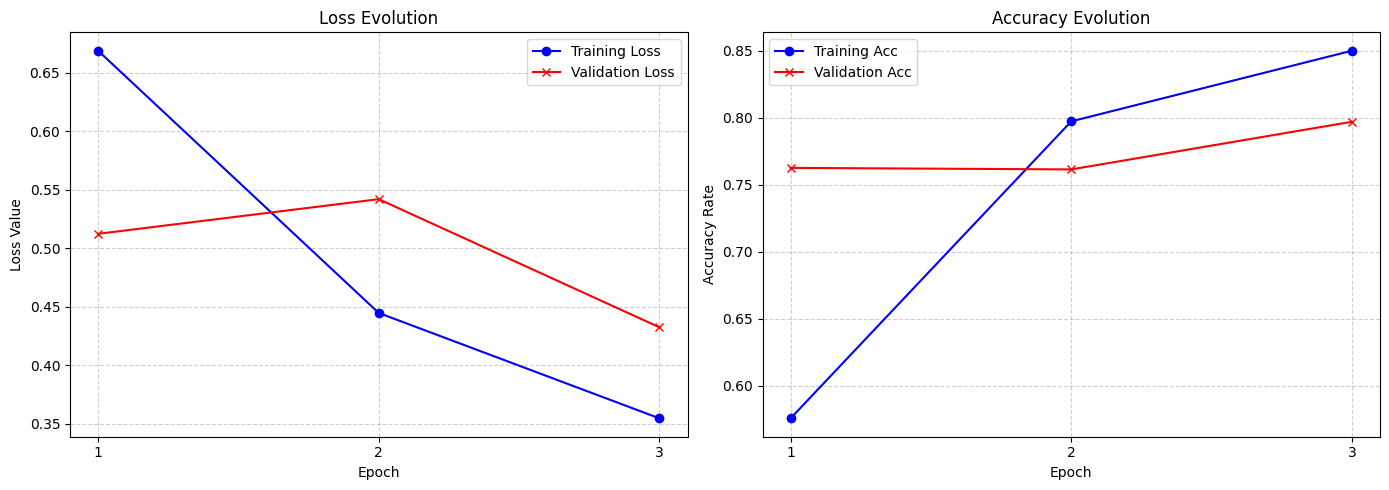

In [28]:
epoch_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_range, train_losses, marker='o', color='blue', label='Training Loss')
axes[0].plot(epoch_range, val_losses,   marker='x', color='red', label='Validation Loss')
axes[0].set_title('Loss Evolution')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss Value')
axes[0].legend()
axes[0].set_xticks(list(epoch_range))
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(epoch_range, train_accs, marker='o', color='blue', label='Training Acc')
axes[1].plot(epoch_range, val_accs,   marker='x', color='red', label='Validation Acc')
axes[1].set_title('Accuracy Evolution')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy Rate')
axes[1].legend()
axes[1].set_xticks(list(epoch_range))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Inference — Predict sentiment for new sentences

In [29]:
def predict_sentiment(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, max_length=MAX_LEN, padding='max_length',
                       truncation=True, return_tensors='pt')

    input_ids = inputs['input_ids'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, token_type_ids, attention_mask)

    probabilities = torch.softmax(outputs, dim=1)
    prediction = outputs.argmax(1).item()
    confidence = probabilities[0][prediction].item()

    label_map = {0: 'Negative', 1: 'Positive'}
    return label_map[prediction], confidence

examples = [
    "This was one of the best experiences I have ever had!",
    "Completely disappointed, would not recommend it to anyone.",
    "The storyline was engaging but the ending fell flat.",
    "Outstanding performance by the entire cast.",
    "Dull and predictable from start to finish.",
]

for text in examples:
    label, score = predict_sentiment(text, model, tokenizer, device)
    print(f'[{label} {score:.2f}]  "{text}"')

[Positive 0.97]  "This was one of the best experiences I have ever had!"
[Negative 0.95]  "Completely disappointed, would not recommend it to anyone."
[Negative 0.72]  "The storyline was engaging but the ending fell flat."
[Positive 0.98]  "Outstanding performance by the entire cast."
[Negative 0.96]  "Dull and predictable from start to finish."


### Parameter Count Summary

In [30]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total Model Size:    {total_params:,} parameters')
print(f'Trainable Subset:    {trainable_params:,} parameters')
print(f'Frozen Backbone:     {total_params - trainable_params:,} parameters')
print(f'\nFine-tuning ratio:  {(100 * trainable_params / total_params):.2f}% of the network.')

Total Model Size:    110,691,842 parameters
Trainable Subset:    1,209,602 parameters
Frozen Backbone:     109,482,240 parameters

Fine-tuning ratio:  1.09% of the network.


## Understanding

Full fine-tuning means we update all weights of BERT-base (~110M parameters). This is heavy work. GPU memory gets almost 3x used because gradients + optimizer (like AdamW) store extra data. On free Colab (T4, 16GB), it becomes tight, and for bigger models it won’t run. Also, for every task we need a full 440MB model copy, so storage becomes an issue. Plus, model can forget old knowledge (catastrophic forgetting).

Adapters fix this smartly. We freeze BERT and add small modules inside each layer. These adapters are very small (~1.2M params, ~1%). So training is fast, less memory, and we only save small adapter files instead of full model. Also, since original model is not changed, it doesn’t forget easily. Still, we get good results (like on SST-2), so adapters are a practical and efficient solution